In [1]:
import cv2
import matplotlib.pyplot as plt
import os
import os.path as osp
import numpy as np

In [2]:
PATH = "img/"
FORMAT = ".png"

In [3]:
def loadAndConvert(img_path):
    img = cv2.imread(f'{PATH + img_path}')    
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.uint8)

def loadColoured(img_path):
    img = cv2.imread(f'{PATH + img_path}')
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img 
   
def showMultipleImages(imgs):
    fig, axes = plt.subplots(1, len(imgs), figsize=(12,12))
    
    for i, img in enumerate(imgs):
        axes[i].imshow(img, cmap='gray')
        axes[i].axis(False)
    plt.tight_layout()

def showImage(img):
    fig, ax = plt.subplots(figsize=(12,12))
    ax.axis(False)
    ax.imshow(img, cmap='gray')

In [71]:
IMGS = list(map(loadAndConvert, sorted(os.listdir(PATH))))

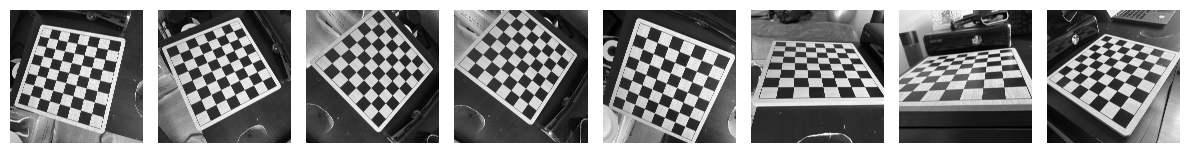

In [72]:
showMultipleImages(IMGS)

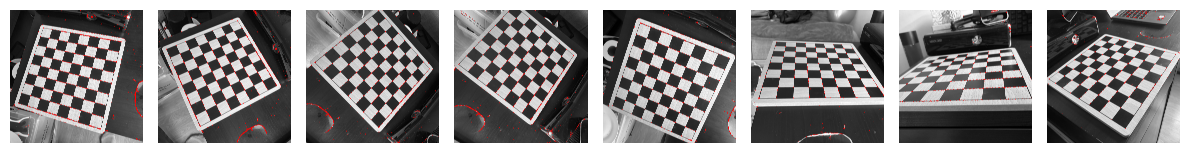

In [ ]:
def harrisCornerDetection(img):
    converted = np.float32(img)

    dest = cv2.cornerHarris(converted, 17, 21, 0, 0.01)
    dest = cv2.dilate(dest, None)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img[dest > 0.01 * dest.max()] = [255,0,0]
    
    return img

IMGS = list(map(loadAndConvert, sorted(os.listdir(PATH))))
IMGS = list(map(harrisCornerDetection, IMGS))
showMultipleImages(IMGS)

In [4]:
BLUR = 1.4

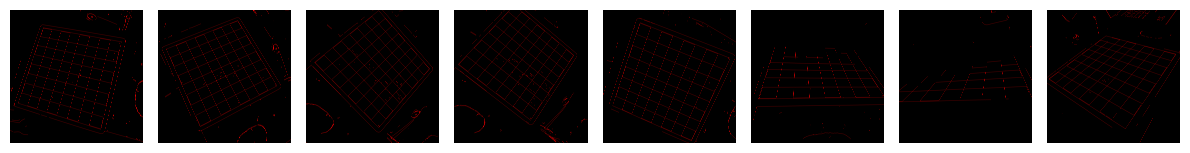

In [5]:
def blurImage(img):
    return cv2.GaussianBlur(img, (5,5), BLUR)

def cannyEdgeDetection(img):
    return cv2.Canny(img, 100, 200)

def findContours(img):
    contours, hierarchy = cv2.findContours(img, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)    
    sorted_contours = sorted(contours, key=lambda c: cv2.arcLength(c, True), reverse=True)[:200]

    return sorted_contours

def drawContours(img, contours):
    return cv2.drawContours(img, contours, contourIdx=-1, color=(255,0,0), thickness=3)

def drawContoursOnBlank(img, contours):
    blank = np.zeros_like(img, np.uint8)
    return cv2.drawContours(blank, contours, contourIdx=-1, color=(255,0,0), thickness=3)

IMGS = list(map(loadAndConvert, sorted(os.listdir(PATH))))
blurred = list(map(blurImage, IMGS))

edges = list(map(cannyEdgeDetection, blurred))
contours = list(map(findContours, edges))

COLOURED_IMAGES = list(map(loadColoured, sorted(os.listdir(PATH))))
drawn = list(map(drawContoursOnBlank, COLOURED_IMAGES, contours))

showMultipleImages(drawn)
